In [ ]:
# Hosted D2L setup: fetch the exact helper module used to build this notebook.
from pathlib import Path
from urllib.request import urlretrieve
from importlib.metadata import PackageNotFoundError, version
import importlib.util, os, subprocess, sys

required = ['numpy', 'pandas', 'matplotlib', 'requests', 'scipy', 'pillow', 'regex', 'torch', 'torchvision']
imports = {'pillow': 'PIL'}
pinned = {}
fallbacks = {'torch': 'torch==2.11.0', 'torchvision': 'torchvision==0.26.0'}
device = os.environ.get("D2L_HOSTED_DEVICE", "auto").lower()
if device not in ("auto", "cpu", "gpu"):
    raise ValueError(f"Invalid D2L_HOSTED_DEVICE={device!r}")
if device == "auto":
    try:
        gpu = (Path("/dev/nvidia0").exists() or
               subprocess.run(["nvidia-smi", "-L"], capture_output=True,
                              timeout=5).returncode == 0)
    except (FileNotFoundError, subprocess.SubprocessError):
        gpu = False
else:
    gpu = device == "gpu"
if not gpu:
    os.environ.setdefault("CUDA_VISIBLE_DEVICES", "-1")
    os.environ.setdefault("JAX_PLATFORMS", "cpu")
tensorflow_version = None
if 'pytorch' in ("tensorflow", "jax"):
    try:
        tensorflow_version = version("tensorflow")
    except PackageNotFoundError:
        pass
# Colab's CPU image currently carries a CUDA-enabled TensorFlow wheel. Its
# first ordinary tensor operation probes CUDA and emits an error-level cuInit
# diagnostic. JAX notebooks also use TensorFlow for data loading, so overlay
# the matching CPU build in both CPU variants. Keep the provider's
# ``tensorflow`` distribution metadata: other preinstalled Colab packages
# depend on that distribution name, while both wheels expose the same module.
if not gpu and 'pytorch' in ("tensorflow", "jax"):
    try:
        tensorflow_cpu_version = version("tensorflow-cpu")
    except PackageNotFoundError:
        tensorflow_cpu_version = None
    if (tensorflow_version is not None and
            tensorflow_cpu_version != tensorflow_version):
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", "--no-deps",
            f"tensorflow-cpu=={tensorflow_version}",
        ])
if "tf-keras" in fallbacks and tensorflow_version is not None:
    fallbacks["tf-keras"] = f"tf-keras=={tensorflow_version}"
missing = []
for package in required:
    if package in pinned:
        wanted, cpu_requirement, gpu_requirement, match = pinned[package]
        requirement = gpu_requirement if gpu else cpu_requirement
        try:
            installed = version(package)
        except PackageNotFoundError:
            installed = None
        actual = (installed.split("+", 1)[0]
                  if installed is not None and match == "public" else installed)
        if actual != wanted:
            missing.append(requirement)
    elif importlib.util.find_spec(imports.get(package, package)) is None:
        missing.append(fallbacks.get(package, package))
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

mismatched = []
for package, (wanted, _, _, match) in pinned.items():
    try:
        installed = version(package)
    except PackageNotFoundError:
        installed = None
    actual = (installed.split("+", 1)[0]
              if installed is not None and match == "public" else installed)
    if actual != wanted:
        mismatched.append(f"{package}={installed!r} (expected {wanted})")
if mismatched:
    raise RuntimeError("Hosted runtime setup failed: " + ", ".join(mismatched))

root = Path(".d2l-hosted") / "8cd319b4f2187b6b29bb69603a96460fc325a975"
package = root / "d2l"
package.mkdir(parents=True, exist_ok=True)
base = "https://raw.githubusercontent.com/smolix/d2l-neu/8cd319b4f2187b6b29bb69603a96460fc325a975/d2l"
for name in ('__init__.py', 'torch.py'):
    target = package / name
    if not target.exists():
        urlretrieve(f"{base}/{name}", target)
if str(root.resolve()) not in sys.path:
    sys.path.insert(0, str(root.resolve()))
pythonpath = os.environ.get("PYTHONPATH", "").split(os.pathsep)
if str(root.resolve()) not in pythonpath:
    os.environ["PYTHONPATH"] = os.pathsep.join(
        [str(root.resolve()), *[entry for entry in pythonpath if entry]]
    )


# GPUs, Devices, and Memory

So far every tensor in this book has lived in main memory and every computation
has run on the CPU. Training at any interesting scale runs on an accelerator,
almost always a CUDA GPU, and that changes two things at once. First, every
tensor and every parameter now has a *home*, a device, and operations only
combine tensors that live on the same one; placing data well is your job.
Second, the GPU's memory is small compared with main memory, typically tens of
gigabytes, and it is the resource you will exhaust first: the daily question of
a single-GPU builder is not "is my model correct?" but "does it fit?". This
section covers both skills: naming devices and placing tensors and models on
them, then measuring what actually fills GPU memory during training, trading
compute for memory when it does not fit, and keeping the device busy once it
does. None of the code requires a GPU to run; the helpers we define fall back
to the CPU, and the memory measurements simply report more interesting numbers
when a GPU is present.

In [1]:
import time
import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.checkpoint import checkpoint
from d2l import torch as d2l

## Devices

In PyTorch every tensor carries a device. The CPU is `torch.device('cpu')` and
it stands for *all* physical CPU cores and all of main memory. A CUDA device
such as `torch.device('cuda:0')` is one specific card and its own memory; on a
machine with several GPUs, `cuda:1` is the second card, and plain `'cuda'` is
shorthand for `cuda:0`. To see what your machine has, run `nvidia-smi` in a
shell: it lists every card, its memory, and what is currently running on it.
We wrap device construction in two helpers that the rest of the book uses.

In [2]:
def cpu():
    """Get the CPU device."""
    return torch.device('cpu')

def gpu(i=0):
    """Get a GPU device."""
    return torch.device(f'cuda:{i}')

cpu(), gpu(), gpu(1)

(device(type='cpu'),
 device(type='cuda', index=0),
 device(type='cuda', index=1))

Note that constructing a device object is free and always succeeds, whether or
not the hardware exists; the check happens only when you try to put data on it.

We can query how many GPUs are actually available.

In [3]:
def num_gpus():
    """Get the number of available GPUs."""
    return torch.cuda.device_count()

num_gpus()

2

Now we define two convenient functions that allow us
to run code even if the requested GPUs do not exist.

In [4]:
def try_gpu(i=0):
    """Return gpu(i) if exists, otherwise return cpu()."""
    if num_gpus() >= i + 1:
        return gpu(i)
    return cpu()

def try_all_gpus():
    """Return all available GPUs, or [cpu(),] if no GPU exists."""
    devices = [gpu(i) for i in range(num_gpus())]
    return devices if devices else [cpu()]

try_gpu(), try_gpu(10), try_all_gpus()

(device(type='cuda', index=0),
 device(type='cpu'),
 [device(type='cuda', index=0), device(type='cuda', index=1)])

CUDA is not the only accelerator string PyTorch understands. Apple-silicon
Macs expose their GPU as `mps`, Intel GPUs appear as `xpu`, and TPUs are
reachable through JAX; PyTorch now bundles the whole family behind the
`torch.accelerator` namespace, whose `device_count()` and
`current_accelerator()` do generically what our helpers do for CUDA. We keep
our own helpers anyway: they give all four of the book's implementations one
vocabulary, and they degrade to the CPU instead of failing, which is exactly
what lets this book's code run unchanged on a laptop. The book standardizes on
CPU plus CUDA; everything below transfers to the other accelerator types with
little more than a renamed device string.

## Tensors, Models, and Devices

By default, tensors are created on the CPU. We can query where a tensor lives.

In [5]:
x = torch.tensor([1, 2, 3])
x.device

device(type='cpu')

To create a tensor somewhere else, pass a `device` argument. Creating data
directly on the target device is better than creating it on the CPU and moving
it: the tensor then never occupies main memory or crosses the bus at all.

In [6]:
X = torch.ones(2, 3, device=try_gpu())
X

tensor([[1., 1., 1.],
        [1., 1., 1.]], device='cuda:0')

On a machine with two GPUs we can put a second tensor on the second card
(on your machine, `try_gpu(1)` substitutes whatever is available).

In [7]:
Y = torch.rand(2, 3, device=try_gpu(1))
Y

tensor([[0.0769, 0.4852, 0.9990],
        [0.3158, 0.7800, 0.9361]], device='cuda:1')

### Copying Between Devices

Whenever we operate on multiple tensors, they need to be on the same device.
If `X` sits on the first GPU and `Y` on the second, `X + Y` raises
`RuntimeError: Expected all tensors to be on the same device`, which is
probably the single most common error message of a beginner's GPU life.
PyTorch refuses to guess: an implicit copy would hide a slow bus transfer
inside an innocent-looking `+`, and you would never find it. Instead we copy
explicitly, as in the figure, and then add.

![X lives on GPU 0 and Y on GPU 1; X.to(gpu(1)) makes a copy Z on GPU 1 (dashed), and Y + Z then runs entirely on GPU 1.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/bg-copyto.svg)

In [8]:
Z = X.to(try_gpu(1))
print(X)
print(Z)

tensor([[1., 1., 1.],
        [1., 1., 1.]], device='cuda:0')
tensor([[1., 1., 1.],
        [1., 1., 1.]], device='cuda:1')


Now that `Z` and `Y` live on the same device, we can add them.

In [9]:
Y + Z

tensor([[1.0769, 1.4852, 1.9990],
        [1.3158, 1.7800, 1.9361]], device='cuda:1')

What if `Z` already lives on the target device? Then `.to` returns `Z` itself
rather than making a copy, so calling it defensively costs nothing.

In [10]:
Z.to(try_gpu(1)) is Z

True

The reason for keeping every copy explicit is the cost model. A
modern GPU multiplies matrices hundreds of times faster than it can receive
data over the PCIe bus, so a transfer in the wrong place can erase the
speedup you bought the GPU for. The discipline that follows is simple: move data to the device
once, at the boundary of the computation, and keep everything inside the
training loop on one device. Many small transfers are worse than one big one,
and a transfer hidden in an inner loop is worst of all.

### Models on a Device

A model is a tree of parameter tensors, and `net.to(device)` moves the whole
tree in one call.

In [11]:
net = nn.Sequential(nn.LazyLinear(1))
net = net.to(device=try_gpu())
net(X)

tensor([[0.5078],
        [0.5078]], device='cuda:0', grad_fn=<AddmmBackward0>)

The input arrived on the device, the parameters live on the device, so the
output is computed and stored there too. Let's confirm where the parameters
ended up.

In [12]:
net[0].weight.device

device(type='cuda', index=0)

Two rules keep models device-clean. Move the model *before* constructing the
optimizer, so that the optimizer's state is created alongside the parameters
it updates. And when `forward` needs a fresh tensor, create it on the input's
device (`torch.zeros(n, device=X.device)`) rather than on the default CPU;
non-parameter state that should follow the model belongs in a buffer
(that section), which `.to(device)` moves along with everything
else.

## GPU Memory

Here is a puzzle that every PyTorch user hits in their first week. You delete
your tensors, yet `nvidia-smi` still shows gigabytes in use; is that a leak?
It is not, and the explanation is the right mental model for everything else
in this section. Requesting memory from the CUDA driver is slow, so PyTorch
uses a *caching allocator*: when a tensor dies, its block is not returned to
the driver but kept in a per-process cache for the next tensor of a similar
size. PyTorch therefore reports two numbers. `torch.cuda.memory_allocated()`
counts bytes held by live tensors; `torch.cuda.memory_reserved()` counts
those bytes plus the cache. `nvidia-smi` sees the process from the outside,
so it reports roughly the reserved figure, which grows to the high-water mark
of your program and stays there. the figure shows how the
three views nest inside one another.

![The three memory views nest: nvidia-smi's driver allocation contains PyTorch's reserved cache, which contains the live tensors that memory_allocated() counts.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/bg-allocator.svg)

In [13]:
if torch.cuda.is_available():
    def report(tag):
        print(f'{tag}: {torch.cuda.memory_allocated() / 2**20:7.1f} MiB '
              f'allocated, {torch.cuda.memory_reserved() / 2**20:7.1f} MiB '
              'reserved')
    big = torch.zeros(256, 1024, 1024, device=gpu())  # 1 GiB of float32
    report('after creating big')
    del big
    report('after deleting it ')
else:
    print('No CUDA device: both counters read 0 on the CPU.')

after creating big:  1032.1 MiB allocated,  1046.0 MiB reserved
after deleting it :     8.1 MiB allocated,  1046.0 MiB reserved


After the deletion, `memory_allocated()` falls by a gibibyte while
`memory_reserved()` does not move: the block went back to the cache, ready for
reuse, and `nvidia-smi` keeps showing it. `torch.cuda.empty_cache()` returns
the cached blocks to the driver, which is occasionally useful when another
process needs the card, but do not call it inside a training loop: it forces
the allocator to make slow driver requests all over again.

### What Fills Memory During Training

In that section we did the bookkeeping on paper: a model with
$N$ parameters costs $4N$ bytes for float32 weights, another $4N$ for their
gradients, and $8N$ for Adam's two moment estimates, roughly $16N$ before any
data arrives. The remaining term, the *activations*, is different in kind:
backpropagation must remember the intermediate results of the forward pass in
order to compute gradients, and their size scales with the batch size and with
the width of every layer, while the $16N$ does not.

We can watch each term arrive by reading `memory_allocated()` at four points
of a single training step.

In [14]:
if torch.cuda.is_available():
    def allocated():
        return f'{torch.cuda.memory_allocated() / 2**20:7.1f} MiB'
    net = nn.Sequential(nn.Linear(1024, 4096), nn.ReLU(),
                        nn.Linear(4096, 4096), nn.ReLU(),
                        nn.Linear(4096, 4096), nn.ReLU(),
                        nn.Linear(4096, 10)).to(gpu())
    opt = torch.optim.Adam(net.parameters())
    X = torch.randn(4096, 1024, device=gpu())
    y = torch.randint(0, 10, (4096,), device=gpu())
    print('weights           ', allocated())
    loss = F.cross_entropy(net(X), y)
    print('+ activations     ', allocated())
    loss.backward()
    print('+ gradients       ', allocated())
    opt.step()
    print('+ optimizer state ', allocated())
else:
    print('No CUDA device: run this cell on a GPU to see the four plateaus.')

weights              168.4 MiB
+ activations        361.5 MiB
+ gradients          321.7 MiB
+ optimizer state    610.1 MiB


The four readings map onto the accounting. The first is the weights alone
(about $4N$ bytes, plus the input batch). The second jumps by the size of the
stored activations — here roughly a third more than the weights; a larger
batch or longer sequence scales this term while the weights stay put. The third *falls* back: `backward` frees the activations as it consumes
them and leaves behind gradients exactly the size of the weights. The fourth
adds $8N$ at the first `opt.step()`, when Adam lazily creates its moment
buffers. From then on the loop cycles between plateaus two and three; the
weights, gradients, and optimizer state are permanent residents. The practical
consequence: when you are out of memory, the knob that works immediately is
the batch size, because it scales the one term the model architecture does not
fix. If a *growing* staircase appears across steps instead of this steady
cycle, look for tensors that keep the computation graph alive between
iterations, such as accumulating `loss` rather than `loss.item()` into a
running total.

### Trading Compute for Memory: Activation Checkpointing

The activation term has a second knob. Backpropagation stores every
intermediate result only to read each one exactly once, on the way back.
*Activation checkpointing* [@Chen.Xu.Zhang.ea.2016] refuses to store
them: it keeps only the inputs to selected segments of the network, and during
the backward pass reruns each segment's forward computation to regenerate the
activations it needs. For a stack of $N$ equally sized layers, dividing the
stack into segments of about $\sqrt{N}$ layers reduces stored activations from
$O(N)$ to $O(\sqrt{N})$. The price is roughly one extra forward pass, often
30--40% more compute per step. the figure sketches
this schedule.
The trade pays off exactly where deep learning spends most of its time: deep
stacks of identical blocks, such as the residual stack we assembled in
that section and every Transformer you will meet later.
We rebuild a compact version of that block here.

![Standard backpropagation stores every activation (top); checkpointing keeps only segment-boundary activations and recomputes the rest during the backward pass (bottom), trading roughly 1.3x compute for O(sqrt(N)) instead of O(N) activation memory.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/bg-activation-checkpoint.svg)

In [15]:
class ResidualBlock(nn.Module):  # As in :numref:`sec_model_construction`
    def __init__(self, num_hiddens):
        super().__init__()
        self.body = nn.Sequential(
            nn.Linear(num_hiddens, num_hiddens), nn.ReLU(),
            nn.Linear(num_hiddens, num_hiddens), nn.ReLU())

    def forward(self, X):
        return X + self.body(X)

def run_stack(blocks, X, use_checkpoint=False, segment_size=4):
    for start in range(0, len(blocks), segment_size):
        stop = min(start + segment_size, len(blocks))
        def segment(X, start=start, stop=stop):
            for i in range(start, stop):
                X = blocks[i](X)
            return X
        X = checkpoint(segment, X, use_reentrant=False) \
            if use_checkpoint else segment(X)
    return X

`torch.utils.checkpoint.checkpoint(segment, X)` runs a segment without storing
its internals and remembers just enough to recompute them later. Recomputation
must reproduce the original forward pass bit for bit, so by default
`checkpoint` also stashes and restores the random-number-generator state,
which keeps segments containing dropout correct at a small extra cost
(`preserve_rng_state=False` skips it for deterministic segments).

Before measuring memory, we should verify the claim that nothing about the
result changes: the gradients through a checkpointed stack must equal the
ordinary ones.

In [16]:
torch.manual_seed(0)
blocks = nn.Sequential(*[ResidualBlock(64) for _ in range(4)])
X = torch.randn(32, 64)

def stack_grads(use_checkpoint):
    blocks.zero_grad(set_to_none=True)
    run_stack(blocks, X, use_checkpoint).sum().backward()
    return [p.grad.clone() for p in blocks.parameters()]

for g, g_ckpt in zip(stack_grads(False), stack_grads(True)):
    assert torch.allclose(g, g_ckpt)
print('checkpointed gradients match the ordinary ones')

checkpointed gradients match the ordinary ones


That check runs anywhere, CPU included. The memory effect needs a GPU and a
stack deep enough for the difference to be unambiguous: sixteen blocks of
width 1024 at batch size 8192.

In [17]:
if torch.cuda.is_available():
    blocks = nn.Sequential(*[ResidualBlock(1024) for _ in range(16)]).to(gpu())
    X = torch.randn(8192, 1024, device=gpu())
    for use_checkpoint in (False, True):
        blocks.zero_grad(set_to_none=True)
        torch.cuda.synchronize()
        torch.cuda.reset_peak_memory_stats()
        t = time.time()
        run_stack(blocks, X, use_checkpoint).sum().backward()
        torch.cuda.synchronize()
        print(f'checkpointing={use_checkpoint!s:5}  peak '
              f'{torch.cuda.max_memory_allocated() / 2**20:6.0f} MiB, '
              f'{time.time() - t:.2f} sec')
else:
    print('No CUDA device: peak-memory comparison needs a GPU.')

checkpointing=False  peak   2358 MiB, 0.04 sec
checkpointing=True   peak   1335 MiB, 0.05 sec


Without checkpointing, the peak carries the activations of all sixteen blocks
at once; with four-block segments, it carries the four segment inputs plus the
recomputed activations of one segment, at the cost of a slower step. When a
model almost fits, this
trade is the difference between training and not training, which is why large
Transformer training runs use it as a matter of course.

## Don't Break the Pipeline

The GPU runs ahead of Python. When you write `B = A @ A`, PyTorch does not
wait for the multiplication: it queues a kernel on the device and returns
immediately, and Python races on to enqueue the next operation. This
asynchrony is where much of the speed comes from, because the CPU can prepare
work while the GPU crunches. It also means that timing or logging naively
measures nothing, or worse, stalls everything. We can see the gap between
*queueing* work and the work *finishing*.

In [18]:
if torch.cuda.is_available():
    A = torch.randn(4096, 4096, device=gpu())
    torch.cuda.synchronize()
    t = time.time()
    for _ in range(32):
        B = A @ A
    print(f'time to queue 32 matrix products: {time.time() - t:.4f} sec')
    torch.cuda.synchronize()
    print(f'time until they all finished:     {time.time() - t:.4f} sec')
else:
    print('No CUDA device: CPU operations run synchronously.')

time to queue 32 matrix products: 0.0014 sec
time until they all finished:     0.0801 sec


Python returned from the loop in a few milliseconds; the products were still
running. Any operation that needs a concrete value on the host forces a
*synchronization point*: `.item()`, `.numpy()`, `print`, an `if` on a tensor's
value. Each one makes Python block until the queue drains, and the device then
sits idle until Python catches up. A `print(loss.item())` in the inner loop
can serialize the whole pipeline this way, once per step, as
the figure lays out. The fix is not to give up monitoring
but to move it off the hot path: keep running statistics on the device and
transfer them once per epoch, or hand values to a background consumer, which
is exactly what our `ProgressBoard` from that section does when the
`Trainer` plots the loss.

![Python queues kernels k1 through k4 and races ahead while the GPU works through them serially; loss.item() forces a synchronization point where the CPU blocks until the GPU drains its queue, then both resume.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/bg-async-queue.svg)

The same overlap idea applies to getting data *onto* the device. An ordinary
host-to-device copy must first move the batch into non-pageable ("pinned")
memory that the DMA engine can read, then transfer it, and the call blocks
Python throughout. If the source already sits in pinned memory, the copy can
be issued with `non_blocking=True` and Python continues immediately, preparing
the next batch while the transfer overlaps the GPU's current work.

In [19]:
if torch.cuda.is_available():
    x = torch.randn(16, 3, 224, 224)  # A typical image batch
    x_pinned = x.pin_memory()
    def copy_time(src, non_blocking=False, n=100):
        torch.cuda.synchronize()
        t = time.time()
        for _ in range(n):
            src.to(gpu(), non_blocking=non_blocking)
        torch.cuda.synchronize()
        return (time.time() - t) / n * 1e3
    print(f'pageable copy:              {copy_time(x):.3f} ms')
    print(f'pinned, non-blocking copy:  {copy_time(x_pinned, True):.3f} ms')
else:
    print('No CUDA device: host-to-device copies do not arise.')

pageable copy:              0.521 ms


pinned, non-blocking copy:  0.408 ms


Two caveats matter. Pinning is itself expensive, so synchronously pinning a
tensor on the training thread just before one copy can erase the benefit.
`DataLoader(pin_memory=True)` performs the pinning in its input pipeline,
while `non_blocking=True` lets the training thread enqueue the transfer without
waiting; this is why the two options are the standard pairing. A
non-blocking copy is a promise, not a completed fact: mutating the source CPU
tensor before the transfer finishes silently corrupts the data on the device.
The full treatment of asynchrony, streams, and multi-device parallelism is in
that section.

## The Trainer, Now with Devices

In that section the `Trainer` accepted a `num_gpus` argument and
ignored it. We can now redeem that promise with everything this section
taught: the model moves to the device *once*, before training, and every batch
streams over per step, at the boundary of the computation.

In [20]:
@d2l.add_to_class(d2l.Trainer)
def __init__(self, max_epochs, num_gpus=0, gradient_clip_val=0):
    self.save_hyperparameters()
    self.gpus = [d2l.gpu(i) for i in range(min(num_gpus, d2l.num_gpus()))]

@d2l.add_to_class(d2l.Trainer)
def prepare_batch(self, batch):
    if self.gpus:
        batch = [d2l.to(a, self.gpus[0]) for a in batch]
    return batch

@d2l.add_to_class(d2l.Trainer)
def prepare_model(self, model):
    model.trainer = self
    model.board.xlim = [0, self.max_epochs]
    if self.gpus:
        model.to(self.gpus[0])
    self.model = model

The `min(num_gpus, d2l.num_gpus())` makes the request a ceiling rather than a
demand: on a machine with no GPU, `self.gpus` is empty, both hooks become
no-ops, and training proceeds on the CPU. Every `Trainer(num_gpus=1)` you see
from the next chapter onward relies on this fallback, which is how one
codebase serves both the laptop you are reading on and a GPU server. As a
capstone we train a classifier built from this chapter's residual blocks on
Fashion-MNIST; the `Trainer` places the model, moves each batch, and the
memory budget of the run is exactly the four-plateau accounting from above.

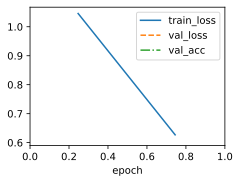

In [21]:
class ResMLPClassifier(d2l.Classifier):
    def __init__(self, num_hiddens=256, num_blocks=2, lr=0.1):
        super().__init__()
        self.save_hyperparameters()
        self.net = nn.Sequential(
            nn.Flatten(), nn.LazyLinear(num_hiddens), nn.ReLU(),
            *[ResidualBlock(num_hiddens) for _ in range(num_blocks)],
            nn.LazyLinear(10))

trainer = d2l.Trainer(max_epochs=1, num_gpus=1)
trainer.fit(ResMLPClassifier(), d2l.FashionMNIST(batch_size=256))

## Summary

Every tensor and every parameter lives on a device, and operations combine
only co-located tensors; copies between devices are explicit (`.to`), slow
relative to compute, and belong at the boundary of the training loop, not
inside it. GPU memory during training holds four things: weights, gradients,
optimizer state (fixed by the model and optimizer), and activations (scaling
with batch size); `memory_allocated()` tracks live tensors while `nvidia-smi`
shows the caching allocator's high-water mark, so the two disagree by design.
Activation checkpointing recomputes instead of stores, trading roughly a third
more compute for activation memory. The GPU runs asynchronously ahead of
Python: `.item()`, `.numpy()`, and `print` are synchronization points that
stall the pipeline, and pinned memory with `non_blocking=True` lets transfers
overlap compute. The `Trainer` encodes the placement discipline: model moved
once, batches moved per step, graceful CPU fallback when no GPU exists.

## Exercises

1. Using the accounting model of this section, predict the peak memory of the
   four-plateau cell at batch sizes 64, 256, and 1024, then measure with
   your framework's peak-memory counter. Where does the prediction break down,
   and what did it omit?
1. Increase the batch size in the checkpointing comparison until the
   non-checkpointed run raises an out-of-memory error. How much further can
   the checkpointed run go before it does too? Explain the ratio using the
   sizes of what each variant stores.
1. Time one epoch of the capstone training run with `print(loss.item())`
   after every step, and again printing only once per epoch. Explain the
   difference in terms of synchronization points.
1. If you have two GPUs, time 1000 matrix products of two $4096 \times 4096$
   matrices executed on one GPU, then 500 on each of two GPUs issued from the
   same loop. You should see almost linear scaling; explain why Python can
   drive both cards at once. Guard the experiment with `num_gpus() >= 2`.